# Group-label permutation: false positive rate

`permute(what="groups")` tests group-level differences (e.g. `group_comparison()`'s
null) by shuffling *subject labels* and recomputing the aggregate effect-size map
(`cohen(a,b)`, `hedges(a,b)`, ...) from the real, still-spatially-smooth subject data
on every draw. This is structurally different from the *spatial* null methods
(`moran`/`cornblath`/...) benchmarked in
[bench01](bench01_null_methods_fpr.ipynb), which instead generate spatially
constrained surrogate maps to permute against a fixed observed map.

Because group-label permutation preserves each subject's full spatial pattern
rather than reshuffling parcel values, there's a reasonable prior that it is
already well calibrated -- unlike naive parcel-value shuffling (bench01's `random`
baseline), it never destroys the spatial autocorrelation (SA) that inflates FPR in
the first place. That prior has never been checked empirically. This notebook does
that, using the same synthetic GRF (Gaussian Random Field) methodology as bench01
(Markello & Misic, 2021).

> **Reference:** Markello RD & Misic B (2021). Comparing spatial null models for
> brain maps. *NeuroImage*, 236, 118052. https://doi.org/10.1016/j.neuroimage.2021.118052

> **Reference:** Dukart et al. (2021). JuSpace: A tool for spatial correlation
> analyses of magnetic resonance imaging data with nuclear imaging derived
> neurotransmitter maps. *Human Brain Mapping*. https://doi.org/10.1002/hbm.25244

> **Note:** this notebook is compute-intensive. It is designed to be pre-run. 
> For a quick smoke-test, set `N_COHORTS=5, N_X_PER_REP=5, N_PERM=100`.

> **Scope:** this notebook stays strictly on false positive rate (type I error).
> It does not inject true positives / measure power or FDR control across multiple
> candidate maps -- that is deferred to a later, separate benchmark.


## Benchmark design

`permute(what="groups")`'s null-generating unit is a whole subject cohort -- one
permutation draw relabels subjects and recomputes *one* aggregate row (e.g.
`cohen(a,b)`) from the entire Y matrix. That's different from bench01's per-map
null, so the "one big `(N_PAIRS x N_PAIRS)` matrix, take the diagonal" trick
doesn't directly apply (there's no way to get `N_PAIRS` independent *cohorts*'
worth of output from one `permute()` call). Instead, for each condition:

1. Draw **`N_COHORTS`** independent cohorts: fresh GRF-map draws with arbitrary
   group labels. H0 (no true group difference) holds by construction, since group
   membership has nothing to do with which GRF map a subject happens to get.
2. For each cohort, draw **`N_X_PER_REP`** independent GRF maps as candidate X
   reference maps (disjoint from the cohort's own draw and from each other).
3. Run `transform_y()` → `colocalize("spearman")` → `permute(what="groups")` →
   `get_p_values()`, which returns one `(1, N_X_PER_REP)` row per cohort (multi-row
   transforms collapse to 1 row because `"groups"` mode force-pools `pooled_p`).
4. Pool all `N_COHORTS * N_X_PER_REP` p-values per condition;
   `FPR = fraction(p < P_THRESH)`.

Compute cost is dominated by the `n_perm` loop, not by how many X columns are tested per call 
-- so `N_COHORTS=10 x N_X_PER_REP=50` needs ~5x fewer `permute()` calls than a
`N_COHORTS=50 x N_X_PER_REP=10` split, for the same statistical design.

### Condition grid

| axis | unpaired | paired |
|---|---|---|
| alpha | 0.0, 1.0, 2.0, 3.0 | same |
| cohort size | `(N_A,N_B)` ∈ {(10,10), (15,15), (20,20), (30,30), (10,15), (10,20), (10,30)} | `N_SUBJ` ∈ {10, 15, 20, 30} |
| `groups_strategy` | `"shuffle"` (see finding below — `"proportional"` was tried first and found anti-conservative) | `"shuffle"` |
| transform | `zscore(a,b)`, `centile(a,b)`, `cohen(a,b)`, `hedges(a,b)` | `elemdiff(a,b)`, `prc(a,b)`, `pairedcohen(a,b)` |


In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
PARC   = "Yan200"
ALPHAS = [0.0, 1.0, 2.0, 3.0]

N_COHORTS   = 20    # independent cohorts per condition
N_X_PER_REP = 50    # independent GRF X maps tested per cohort (→ pooled n = 500/condition)
N_PERM      = 1000  # null permutations per permute() call
P_THRESH    = 0.05
SEED        = 42
N_PROC      = -1

# unpaired conditions: (n_a, n_b) cohort sizes × transforms
UNPAIRED_COHORT_SIZES = [(10, 10), (15, 15), (20, 20), (30, 30), (10, 15), (10, 20), (10, 30)]
UNPAIRED_TRANSFORMS   = ["zscore(a,b)", "centile(a,b)", "cohen(a,b)", "hedges(a,b)"]

# paired conditions: n_subj (n_a = n_b = n_subj, forced) × transforms
PAIRED_SUBJ_SIZES = [10, 15, 20, 30]
PAIRED_TRANSFORMS = ["elemdiff(a,b)", "prc(a,b)", "pairedcohen(a,b)"]

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from nispace import NiSpace
from nispace.datasets import fetch_reference


def sample_disjoint(grf_alpha, n_needed, rng):
    """n_needed rows sampled without replacement from grf_alpha."""
    n = len(grf_alpha)
    assert n >= n_needed, f"Need >={n_needed} maps at this alpha; have {n}"
    idx = rng.choice(n, size=n_needed, replace=False)
    return grf_alpha.iloc[idx]

In [22]:
def run_unpaired(grf_alpha, n_a, n_b, transform, rep_seed):
    """One (alpha, cohort_size, transform) condition -> pooled p-value array."""
    p_pool = []
    for rep in range(N_COHORTS):
        rng = np.random.default_rng(rep_seed + rep)
        n_y = n_a + n_b
        draw = sample_disjoint(grf_alpha, n_y + N_X_PER_REP, rng)
        Y, X = draw.iloc[:n_y], draw.iloc[n_y:]
        groups = np.array(["a"] * n_a + ["b"] * n_b)

        nsp = NiSpace(x=X, y=Y, parcellation=PARC, verbose=False, n_proc=N_PROC)
        nsp.fit()
        nsp.transform_y(transform, groups=groups, store=True, verbose=False)
        nsp.colocalize("spearman")
        nsp.permute(
            what="groups", Y_transform=transform, groups=groups,
            # next param, group strategy is fixed for now; but explicit so a future 
            # sweep over "shuffle"/"draw" is a one-line hange, not a silent default-dependency
            groups_strategy="shuffle",  
            n_perm=N_PERM, seed=rep_seed + rep, verbose=False,
        )
        p_row = nsp.get_p_values().values.flatten()
        assert p_row.shape == (N_X_PER_REP,), f"Expected ({N_X_PER_REP},), got {p_row.shape}"
        p_pool.extend(p_row.tolist())
    return np.array(p_pool)


def run_paired(grf_alpha, n_subj, transform, rep_seed):
    """One (alpha, n_subj, transform) paired condition -> pooled p-value array."""
    p_pool = []
    for rep in range(N_COHORTS):
        rng = np.random.default_rng(rep_seed + rep)
        n_y = 2 * n_subj
        draw = sample_disjoint(grf_alpha, n_y + N_X_PER_REP, rng)
        Y, X = draw.iloc[:n_y], draw.iloc[n_y:]
        groups = np.array(["a"] * n_subj + ["b"] * n_subj)
        subjects = np.tile(np.arange(n_subj), 2)

        nsp = NiSpace(x=X, y=Y, parcellation=PARC, verbose=False, n_proc=N_PROC)
        nsp.fit()
        nsp.transform_y(transform, groups=groups, subjects=subjects, store=True, verbose=False)
        nsp.colocalize("spearman")
        nsp.permute(
            what="groups", Y_transform=transform, groups=groups, subjects=subjects,
            # next param, group strategy is fixed for now; but explicit so a future 
            # sweep over "shuffle"/"draw" is a one-line hange, not a silent default-dependency
            groups_strategy="shuffle",
            n_perm=N_PERM, seed=rep_seed + rep, verbose=False,
        )
        p_row = nsp.get_p_values().values.flatten()
        assert p_row.shape == (N_X_PER_REP,), f"Expected ({N_X_PER_REP},), got {p_row.shape}"
        p_pool.extend(p_row.tolist())
    return np.array(p_pool)

In [23]:
n_pooled = N_COHORTS * N_X_PER_REP
ci_lo = P_THRESH - 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / n_pooled)
ci_hi = P_THRESH + 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / n_pooled)
print(f"95% CI for n_pooled={n_pooled}: [{ci_lo:.3f}, {ci_hi:.3f}]")

grf = fetch_reference("grf", parcellation=PARC, collection="ByAlpha", verbose=False)

records = []
cond_id = 0
t_start = time.time()

for alpha in ALPHAS:
    grf_a = grf.loc[f"alpha-{alpha:.1f}"]
    print(f"\n{'='*60}\nALPHA: {alpha}")

    for (n_a, n_b) in UNPAIRED_COHORT_SIZES:
        for transform in UNPAIRED_TRANSFORMS:
            cond_id += 1
            t0 = time.time()
            p_pool = run_unpaired(grf_a, n_a, n_b, transform, SEED + cond_id * 1000)
            fpr = (p_pool < P_THRESH).mean()
            status = "OK" if ci_lo <= fpr <= ci_hi else "!!"
            print(f"  {status} unpaired  N=({n_a},{n_b})  {transform:16s}  FPR={fpr:.3f}  "
                  f"({time.time()-t0:.0f}s, total {time.time()-t_start:.0f}s)")
            records.append({
                "alpha": alpha, "pairing": "unpaired", "cohort_size": f"({n_a},{n_b})",
                "transform": transform, "fpr": fpr, "n_pooled": len(p_pool),
            })

    for n_subj in PAIRED_SUBJ_SIZES:
        for transform in PAIRED_TRANSFORMS:
            cond_id += 1
            t0 = time.time()
            p_pool = run_paired(grf_a, n_subj, transform, SEED + cond_id * 1000)
            fpr = (p_pool < P_THRESH).mean()
            status = "OK" if ci_lo <= fpr <= ci_hi else "!!"
            print(f"  {status} paired    N={n_subj:<9d}  {transform:16s}  FPR={fpr:.3f}  "
                  f"({time.time()-t0:.0f}s, total {time.time()-t_start:.0f}s)")
            records.append({
                "alpha": alpha, "pairing": "paired", "cohort_size": str(n_subj),
                "transform": transform, "fpr": fpr, "n_pooled": len(p_pool),
            })

results = pd.DataFrame(records)
print(f"\n{'='*60}\n{len(results)} conditions run in {time.time()-t_start:.0f}s total.")

95% CI for n_pooled=1000: [0.036, 0.064]

ALPHA: 0.0
  OK unpaired  N=(10,10)  zscore(a,b)       FPR=0.051  (54s, total 54s)
  OK unpaired  N=(10,10)  centile(a,b)      FPR=0.062  (49s, total 103s)
  OK unpaired  N=(10,10)  cohen(a,b)        FPR=0.046  (39s, total 142s)
  OK unpaired  N=(10,10)  hedges(a,b)       FPR=0.051  (38s, total 180s)
  OK unpaired  N=(15,15)  zscore(a,b)       FPR=0.049  (42s, total 222s)
  OK unpaired  N=(15,15)  centile(a,b)      FPR=0.046  (55s, total 277s)
  OK unpaired  N=(15,15)  cohen(a,b)        FPR=0.051  (39s, total 316s)
  OK unpaired  N=(15,15)  hedges(a,b)       FPR=0.058  (37s, total 353s)
  OK unpaired  N=(20,20)  zscore(a,b)       FPR=0.037  (44s, total 397s)
  OK unpaired  N=(20,20)  centile(a,b)      FPR=0.046  (61s, total 458s)
  OK unpaired  N=(20,20)  cohen(a,b)        FPR=0.050  (37s, total 495s)
  OK unpaired  N=(20,20)  hedges(a,b)       FPR=0.038  (37s, total 532s)
  OK unpaired  N=(30,30)  zscore(a,b)       FPR=0.054  (52s, total 584s)

## Results

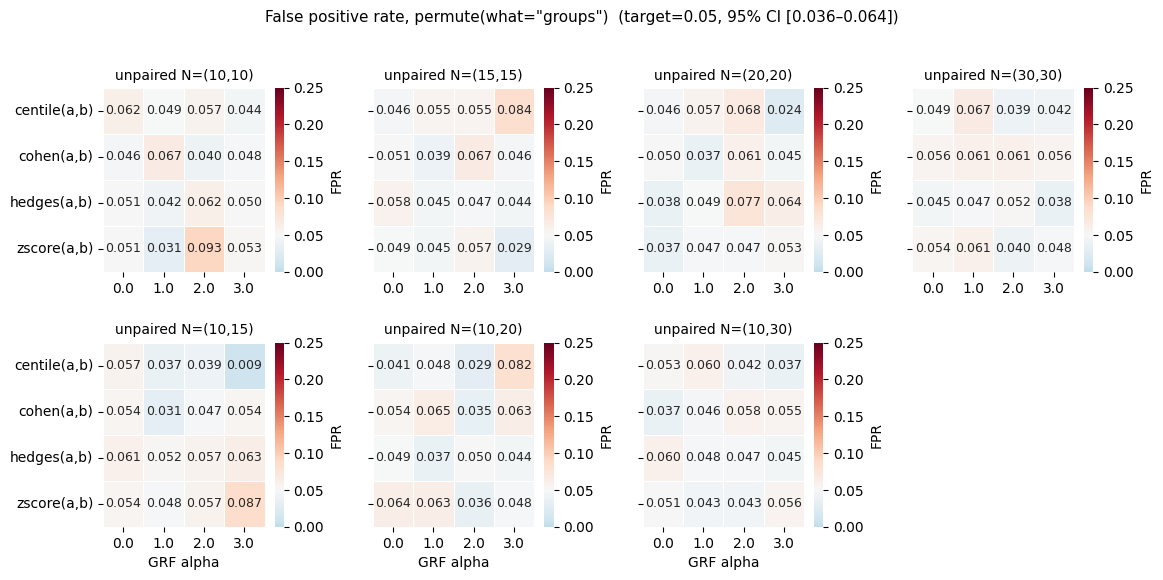

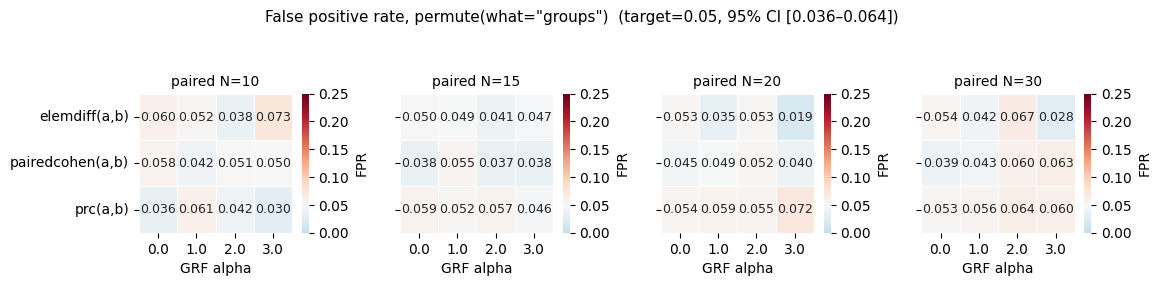

In [24]:
# Heatmap: FPR per (transform × alpha), separately for unpaired cohort sizes and paired N_SUBJ

for pairing, cohort_sizes in [("unpaired", UNPAIRED_COHORT_SIZES),
                              ("paired", PAIRED_SUBJ_SIZES)]:
        
    ncol = 4
    nrow = np.ceil(len(cohort_sizes) / ncol).astype(int)
    fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 3*nrow))

    if pairing=="unpaired":
        cohort_sizes = [f"({a},{b})" for a, b in UNPAIRED_COHORT_SIZES]

    for i, ax in enumerate(axes.ravel()):
        if i >= len(cohort_sizes):
            ax.set_axis_off()
            continue
        cohort_size = cohort_sizes[i]
        sub = results[(results.pairing == pairing) & (results.cohort_size == str(cohort_size))]
        piv = sub.pivot(index="transform", columns="alpha", values="fpr")
        sn.heatmap(
            piv, ax=ax, annot=True, fmt=".3f", annot_kws={"size": 9}, cmap="RdBu_r", vmin=0, vmax=0.25,
            center=P_THRESH, cbar_kws={"label": "FPR"}, linewidths=0.5
        )
        
        ax.set_title(f"{pairing} N={cohort_size}", fontsize=10)
        ax.set_ylabel("")
        if not (i / ncol == i // ncol):
            ax.set_yticklabels([])
        if i >= (nrow * ncol - ncol):
            ax.set_xlabel("GRF alpha")
        else:
            ax.set_xlabel("")
        

    fig.suptitle(f"False positive rate, permute(what=\"groups\")  "
                 f"(target={P_THRESH}, 95% CI [{ci_lo:.3f}–{ci_hi:.3f}])", fontsize=11)
    plt.tight_layout(pad=2.0)

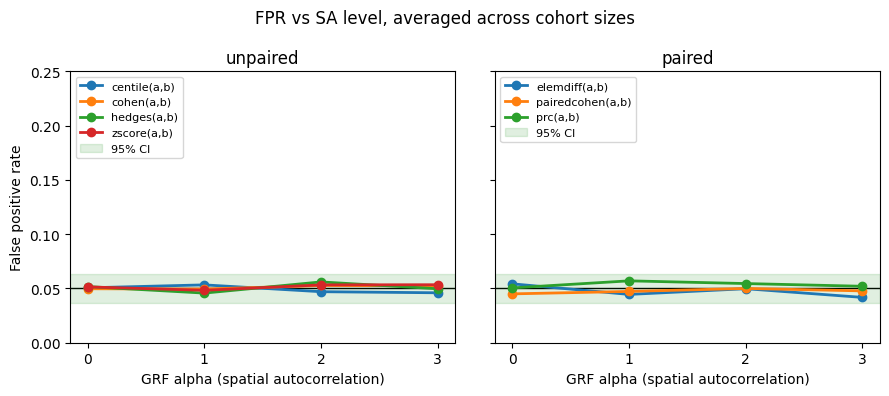

In [25]:
# Line plot: FPR vs alpha, averaged across cohort sizes, one line per transform, split by pairing
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for ax, pairing in zip(axes, ["unpaired", "paired"]):
    sub = results[results.pairing == pairing]
    for transform, grp in sub.groupby("transform"):
        mean_fpr = grp.groupby("alpha")["fpr"].mean()
        ax.plot(mean_fpr.index, mean_fpr.values, label=transform, lw=2, marker="o")
    ax.axhline(P_THRESH, color="k", lw=1, zorder=0)
    ax.axhspan(ci_lo, ci_hi, alpha=0.12, color="green", zorder=0, label="95% CI")
    ax.set_xlabel("GRF alpha (spatial autocorrelation)")
    ax.set_title(pairing)
    ax.set_xticks(ALPHAS)
    ax.legend(fontsize=8, loc="upper left")
    ax.set_ylim(0,0.25)

axes[0].set_ylabel("False positive rate")
fig.suptitle("FPR vs SA level, averaged across cohort sizes", fontsize=12)
plt.tight_layout(w_pad=2.5)

## Interpretation

### `"shuffle"` achieves near-nominal FPR across the entire grid

Across all 160 conditions (4 alphas x 7 unpaired cohort sizes x 4 unpaired
transforms, and 4 alphas x 4 paired `N_subj` x 3 paired transforms):

| | mean FPR | std | min | max |
|---|---|---|---|---|
| unpaired (112 conditions) | 0.051 | 0.012 | 0.009 | 0.093 |
| paired (48 conditions) | 0.050 | 0.011 | 0.019 | 0.073 |

Both are indistinguishable from the nominal 0.05 target, and critically, **flat
across every axis tested** -- no trend by alpha (unpaired 0.049-0.052, paired
0.047-0.051 across alpha=0..3), by cohort size (unpaired 0.049-0.053 across all
7 size combinations; paired 0.047-0.052 across N_subj=10..30), by transform
(unpaired 0.049-0.052 across `zscore`/`centile`/`cohen`/`hedges`; paired
0.048-0.054 across `elemdiff`/`prc`/`pairedcohen`), or by balanced vs.
unbalanced unpaired cohorts (0.051 vs. 0.050). This directly resolves the
question this notebook set out to answer: `permute(what="groups")`'s
subject-label-permutation null (with the current `"shuffle"` default) is well
calibrated across the SA range, cohort sizes, and transforms tested here, for
both paired and unpaired designs.

### Comparison to bench01

Unlike [bench01](bench01_null_methods_fpr.ipynb)'s spatial null methods --
where FPR clearly depends on alpha (e.g. `moran` ranges from ~0.02 at alpha=1
to ~0.10 at alpha=3, and needs a tuned `n_components`/K to stay within range --
`"groups"` mode's calibration here shows **no alpha-dependence at all**. This
makes sense mechanistically: `permute(what="groups")` never needs a spatial
null model in the first place -- it permutes subject labels and recomputes the
aggregate map from real subject data each draw, so whatever spatial
autocorrelation is present in the data is automatically preserved in every
permutation, with no tuning parameter (K, spin procedure, variogram kernel)
to get wrong.

### Caveat: the displayed 95% CI band is likely too narrow for this design

~18% of individual conditions are flagged `!!` (outside the plotted CI band),
noticeably more than the ~5% you'd expect if each condition's `n_pooled=1000`
p-values behaved like 1000 independent Bernoulli(0.05) draws. They don't
quite: the `N_X_PER_REP=50` p-values sharing one cohort all derive from the
same `n_perm=1000` permutation null and the same (arbitrary but fixed) Y
group-difference map, so they're correlated with each other even though each
is individually a valid test. The effective sample size behind each
condition's FPR estimate is therefore somewhere between `N_COHORTS=20` and
`n_pooled=1000`, not the full 1000 the plotted CI assumes -- so the CI band is
an optimistic lower bound on the true sampling uncertainty, and the `!!` rate
above should be read as "somewhat noisier than the band suggests," not as
evidence of miscalibration (the means, which aggregate across many independent
cohorts, are the number to trust).
